# Pytorch Computer Vision

## 0. Computer vision libraries
* `torchvision` - base domain library for Pytorch computer vision
* `torchvision.datasets` - get datasets and data loading functions for computer vision
* `torchvision.models` - get pretrained computer vision models that can be leveraged for own problem
* `torchvision.transforms` - functions for manipulating vision data (images) to be suitable for use with ML model
* `torch.utils.data.Dataset` - Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates python iterable over a dataset

In [1]:
import torch
from torch import nn
import torchvision
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import matplotlib as mpl

print(torch.__version__)
print(torchvision.__version__)

2.11.0
0.26.0


## 1.1 Getting a dataset

We'll be using FashionMNIST

In [2]:
train_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)



In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

## 1.3 Check input and output shapes of data

In [7]:
# Check the shape
print(f"Image shape: {image.shape}, Image label: {train_data.classes[label]}")

Image shape: torch.Size([1, 28, 28]), Image label: Ankle boot


## 1.4 Visualizing Data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

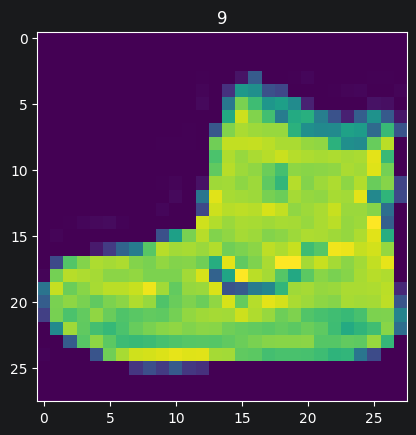

In [8]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

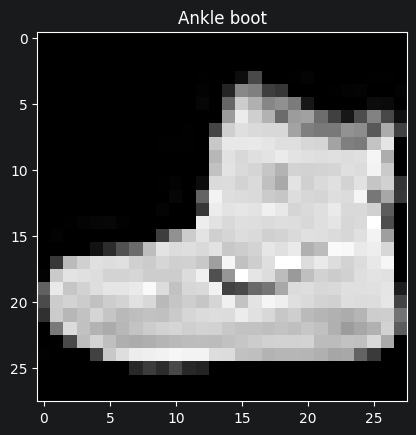

In [9]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(train_data.classes[label])

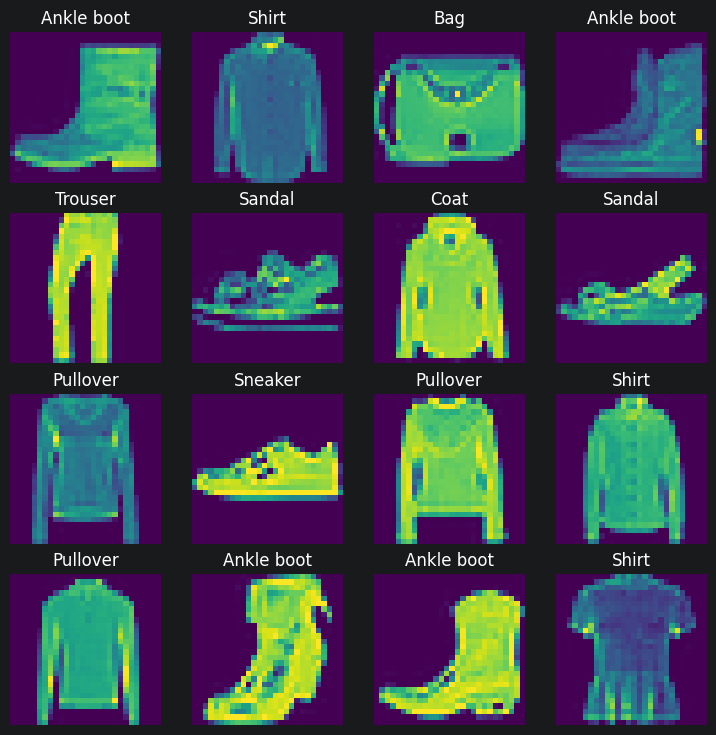

In [10]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze())
    plt.title(train_data.classes[label])
    plt.axis('off')


# 2. Prepare DataLoader

Right now, data is in the form of PyTorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches (or mini batches)

But Why?
1. It is more computationally efficient, as in, computing hardware may not be able to look at (store in memory) at 60000 images in one hit. So we break it dwn to 32 images at a time (batch size of 32).
2. It gives our neural network more chances to update its gradient per epoch.

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
# turn datasets into iterable (datasets)
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x11396d2b0>,
 <torch.utils.data.dataloader.DataLoader at 0x113f61810>)

In [12]:
print("Length of train dataloader: ", len(train_dataloader))
print("Length of test dataloader: ", len(test_dataloader))

Length of train dataloader:  1875
Length of test dataloader:  313


In [13]:
# What's inside the training data loader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28]), Image label: Shirt, Label size: torch.Size([])


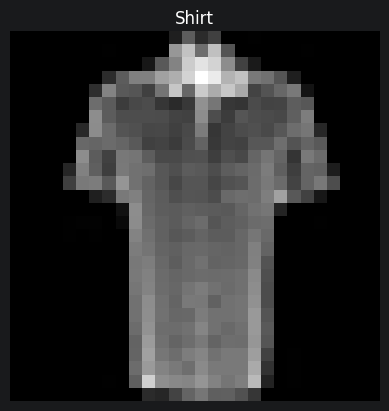

In [14]:
# show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.axis('off')
print(f"Image size: {img.shape}, Image label: {train_data.classes[label]}, Label size: {label.shape}")

# 3. Build Baseline Model 0

A baseline model is a simple model you will try and improve upon with subsequent models/experiemets

* Start simply and add complexity when necessary

In [15]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]
print(x.shape)

output = flatten_model(x)
print(output.shape)

# [color_channels, height, width] -> [color_channels, height*width]


torch.Size([1, 28, 28])
torch.Size([1, 784])


In [16]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

In [17]:
torch.manual_seed(42)

# setup model with input params
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to("cpu")



In [18]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## 3.1 Pick Loss Function and Optimizer

* Loss Function - since we have multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.optim.SGD`
* Evaluation Metric - use accuracy as our evaluation metric. Since accuracy is a classification evaluation metric

In [19]:
# Import accuracy metric from helper functions
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

## 3.2 Creating function to time our experiments
Machine learning is very experimental
Will often want to track
1. Model's performance (loss and accuracy values etc)
2. How fast it runs

In [20]:
from timeit import default_timer as timer, default_timer


def print_train_time(start: float, end: float, device: torch.device = None) -> float:
    """ prints difference between start time and end time """
    elapsed = end - start
    print(f"Training time on {device}: {elapsed:.3f} seconds")
    return elapsed

start_time = timer()
# some code...
end_time = timer()
print_train_time(start_time, end_time, device=torch.device("cpu"))

Training time on cpu: 0.000 seconds


8.375151082873344e-06

# 3.3 Creating a training loop
Creating a training loop and training model on batches of data

1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss per batch
3. Loop through testing batches, perform testing steps, calculate the test loss per batch
4. Print out status
5. Time it all (for fun)

In [21]:
from tqdm.auto import tqdm
import ipywidgets
# set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs. (small for faster training time and iterative improvements)
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---")
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # Forward pass
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader)} samples")
    # Avg training loss per batch per epoch
    # Divide total train loss by length of train data loader
    train_loss /= len(train_dataloader)

    # Testing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test)
            test_loss += loss_fn(test_pred, y_test)
            test_acc += accuracy_fn(y_test, test_pred.argmax(dim=1))
        # Calculate the test loss/acc average per batch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

train_time_end_on_cpu = timer()
total_time_model_0 = print_train_time(train_time_start_on_cpu, train_time_end_on_cpu, device=str(next(model_0.parameters()).device))
print(total_time_model_0)



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
---
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples

Train loss: 0.5904 | Test loss: 0.5095 | Test accuracy: 82.0387
Epoch 1
---
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples

Train loss: 0.4763 | Test loss: 0.4799 | Test accuracy: 83.1969
Epoch 2
---
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples

Train loss: 0.4550 | Test loss: 0.4766 | Test accuracy: 83.4265
Training time on cpu: 7.555 seconds
7.555309416959062


# 4. Evaluate Model

In [22]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device = torch.device("cpu")) -> dict:
    """ Returns dictionary containing the results of a model predicting on a dataloder"""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X, y = X.to(device), y.to(device)
            # Make predictions
            y_pred = model(X)

            # Accumulate loss and acc values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y, y_pred.argmax(dim=1))
        # Scale loss and acc to find avg
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, "model_loss": loss, "model_accuracy": acc}

#  Calculate model 0 results on test data
model_0_results = eval_model(model=model_0, data_loader=train_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/1875 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': tensor(0.4303),
 'model_accuracy': 84.94166666666666}

# 5. Building a better model with Non-linearity

In [23]:
device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)

In [24]:
# Create model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # Flatten inputs into a single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)

model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

## 5.1 Create loss function and optimizer

In [25]:
# Import accuracy metric from helper functions
from helper_functions import accuracy_fn

loss_fn = CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)


## 5.2 Turning training loop into a function
Create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`


In [26]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device,
):
    """
    Perform training with model trying to learn on data loader.

    :param model:
    :param train_dataloader:
    :param loss_fn:
    :param optimizer:
    :param accuracy_fn:
    :param device:
    :return:
    :rtype:
    """
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        # Forward pass
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Avg training loss per batch per epoch
    # Divide total train loss by length of train data loader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%\n")

def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device,
):
    """
    Perform testing with model trying to learn on data loader.

    :param model:
    :param data_loader:
    :param loss_fn:
    :param optimizer:
    :param accuracy_fn:
    :param device:
    :return:
    :rtype:
    """

    # Testing
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
        # Calculate the test loss/acc average per batch
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

    print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [27]:
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n------")
    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_step(model=model_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end_on_gpu = timer()
total_train_time_model1 = print_train_time(train_time_start_on_gpu, train_time_end_on_gpu, device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
------
Train loss: 0.69330 | Train accuracy: 75.74%


Test loss: 0.55063 | Test accuracy: 80.61%

Epoch 1
------
Train loss: 0.49621 | Train accuracy: 82.27%


Test loss: 0.49627 | Test accuracy: 82.40%

Epoch 2
------
Train loss: 0.46770 | Train accuracy: 83.27%


Test loss: 0.48576 | Test accuracy: 82.74%

Training time on mps: 19.178 seconds


In [28]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': tensor(0.4858, device='mps:0'),
 'model_accuracy': 82.7376198083067}

# 7. Building a Convolutional Neural Network (CNN)

CNN's are known for their capabilities to find patterns in visual data

In [29]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture that replicates the TinyVGG
    model from CNN Explainer website.
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

In [30]:
torch.manual_seed(42)
class_names = train_data.classes
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names))
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [31]:
rand_img_tensor = torch.randn(size=(1, 28, 28))
model_2(rand_img_tensor.unsqueeze(0))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

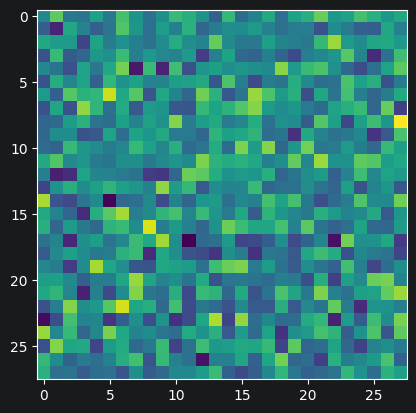

In [32]:
plt.imshow(rand_img_tensor.squeeze())

## 7.1 Stepping through `nn.Conv2d()`


In [33]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: {test_image}")


Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image: tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.

In [34]:
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0)
conv_output = conv_layer(test_image)
conv_output

tensor([[[-2.8778e-01, -6.0596e-02, -5.6305e-02,  ...,  2.8654e-01,
           6.6224e-01, -2.3216e-01],
         [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
          -1.8551e-01, -5.7622e-01],
         [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
           1.4923e-01,  1.4236e-01],
         ...,
         [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
           4.2594e-01, -4.8341e-01],
         [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
          -3.6626e-01,  3.5645e-01],
         [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
          -4.9680e-01, -7.2258e-01]],

        [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
          -1.7643e+00,  2.5263e-01],
         [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
           4.8068e-01,  8.4869e-01],
         [ 6.4927e-01, -4.2060e-03, -4.9991e-01,  ...,  5.8356e-01,
           2.4611e-01,  6.6233e-01],
         ...,
         [ 9.8860e-02,  1

## 7.2 Stepping through `nn.MaxPool2d()`

In [35]:
test_image.shape

torch.Size([3, 64, 64])

In [36]:
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# Create sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)

test_image_through_conv = conv_layer(test_image)
print(f"Shape after going through conv_layer: {test_image_through_conv.shape}")

# Pass data throug max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through max_pool_layer: {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer: torch.Size([10, 62, 62])
Shape after going through max_pool_layer: torch.Size([10, 31, 31])


In [37]:
torch.manual_seed(42)

# Create random tensor with similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor: {random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")
# Create max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass random tensor through max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"Shape after going through max_pool_layer: {max_pool_tensor.shape}")
print(f"Max pool tensor: {max_pool_tensor}")


Random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])
Shape after going through max_pool_layer: torch.Size([1, 1, 1, 1])
Max pool tensor: tensor([[[[0.3367]]]])


## 7.3 Setup a loss function and Optimizer for `model_2`

In [38]:
# setup loss function/eval metrics/optimizer
from helper_functions import accuracy_fn

model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)


## 7.4 Training and testing `model_2`

In [39]:
torch.manual_seed(42)


# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n-----")

    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(train_time_start_model_2, train_time_end_model_2, device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
-----
Train loss: 0.60772 | Train accuracy: 78.07%


Test loss: 0.40357 | Test accuracy: 85.54%

Epoch 1
-----
Train loss: 0.37569 | Train accuracy: 86.39%


Test loss: 0.36771 | Test accuracy: 86.75%

Epoch 2
-----
Train loss: 0.33586 | Train accuracy: 87.85%


Test loss: 0.33697 | Test accuracy: 87.88%

Training time on mps: 27.228 seconds


In [40]:
# Get model_2 results
model_2_results = eval_model(model_2, test_dataloader, loss_fn, accuracy_fn, device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3370, device='mps:0'),
 'model_accuracy': 87.879392971246}

# 8. Compare model results and training time

In [41]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_accuracy
0,FashionMNISTModelV0,tensor(0.4303),84.941667
1,FashionMNISTModelV1,"tensor(0.4858, device='mps:0')",82.737620
2,FashionMNISTModelV2,"tensor(0.3370, device='mps:0')",87.879393


In [42]:
# Add training time to results comparison

compare_results["training_time"] = [total_time_model_0, total_train_time_model1, total_train_time_model_2]
compare_results

,model_name,model_loss,model_accuracy,training_time
0,FashionMNISTModelV0,tensor(0.4303),84.941667,7.555309
1,FashionMNISTModelV1,"tensor(0.4858, device='mps:0')",82.737620,19.178442
2,FashionMNISTModelV2,"tensor(0.3370, device='mps:0')",87.879393,27.228466


Text(0, 0.5, 'model')

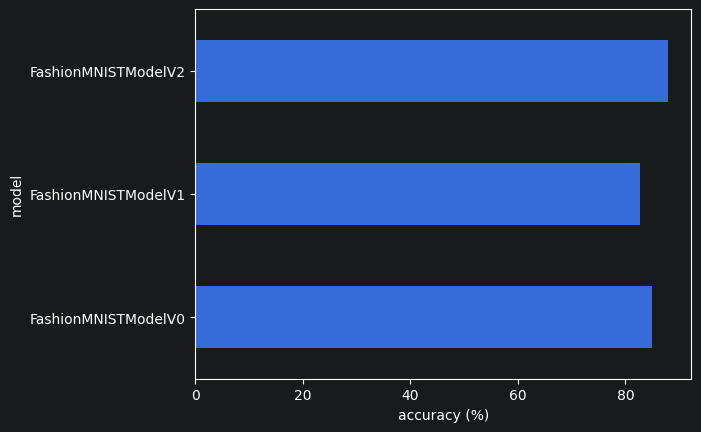

In [43]:
# Visualize model results
compare_results.set_index("model_name")["model_accuracy"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

In [44]:
def make_predictions(model: torch.nn.Module, data:list, device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare the sample ( add batch dimension and pass to target device)
            sample = torch.unsqueeze(sample, dim=0).to(device)
            # Forward pass (model outputs raw logits)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Get pred_prob off gpu for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [45]:
import random
# random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first sample shape
test_samples[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Coat')

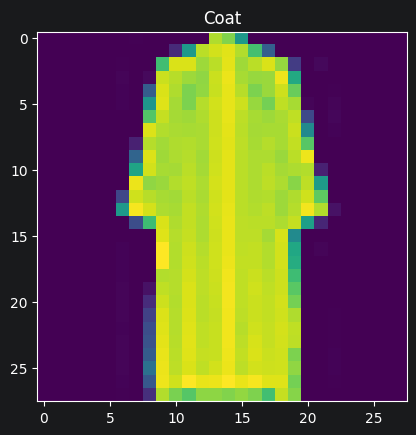

In [46]:
plt.imshow(test_samples[0].squeeze())
plt.title(class_names[test_labels[0]])

In [47]:
# Make predictions
pred_probs = make_predictions(model_2, test_samples, device)

# View first two prediction probabilities
pred_probs[:2]

tensor([[5.5125e-03, 4.9211e-04, 8.9700e-04, 7.2295e-01, 2.6250e-01, 9.3153e-06,
         3.9733e-03, 1.5521e-04, 3.5039e-03, 1.3247e-06],
        [8.3849e-07, 1.7495e-07, 2.6039e-06, 4.6611e-07, 1.7227e-07, 9.9616e-01,
         2.7194e-07, 3.1559e-03, 4.8819e-04, 1.8698e-04]])

In [48]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([3, 5, 6, 0, 9, 4, 4, 9, 4])

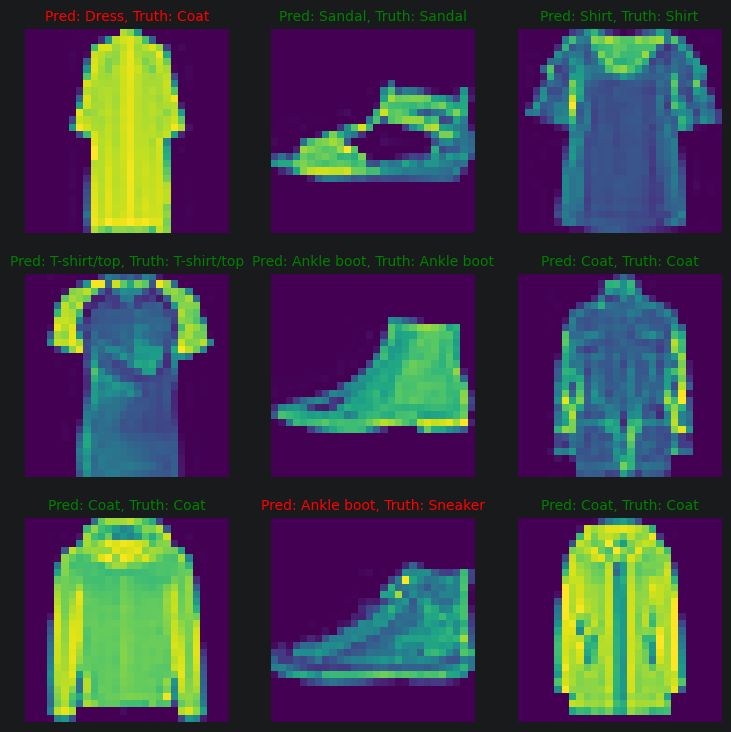

In [49]:
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)

    # plot target image
    plt.imshow(sample.squeeze())

    # Find prediction label in text form
    pred_label = class_names[pred_classes[i]]

    # Get truth label
    truth_label = class_names[test_labels[i]]

    # Create title for the plot
    title_text = f"Pred: {pred_label}, Truth: {truth_label}"

    # Check for equality between pred and truth and chnge color of title text
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, color="green")
    else:
        plt.title(title_text, fontsize=10, color="red")
    plt.axis(False)

# 9. Making a confusion Matrix for further prediction evaluation

A confusion matrix is a fantastic way of evaluating your classification models visually

`torchmetrics.ConfusionMatrix`

`mlxtend.plotting.plot_confusion_matrix()`

In [50]:
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        X, y = X.to(device), y.to(device)

        y_logit = model_2(X)
        y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
        y_preds.append(y_pred.cpu())

# Concat list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor
len(y)

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

16

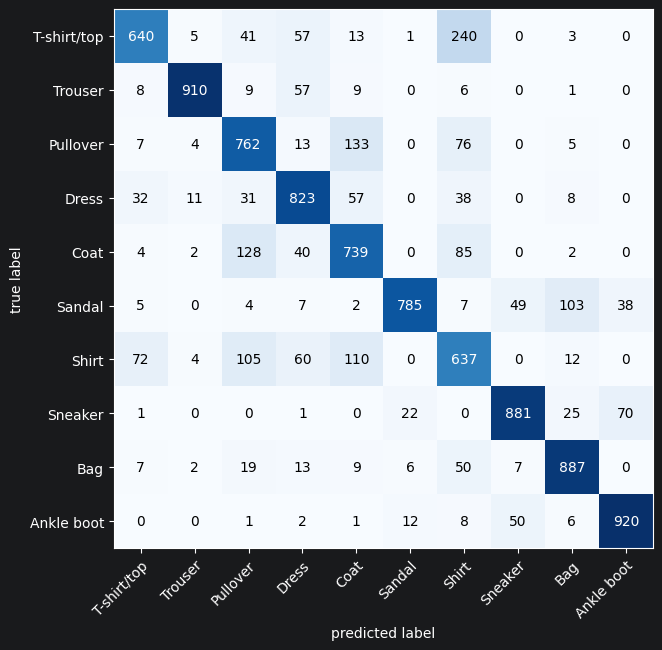

In [51]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

# plot confusion matrix

fig, ax = plot_confusion_matrix(
    confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7),
)

# Save and Load Best Performing Model

In [52]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "03_pytorch_computer_vision_cnn.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
torch.save(model_2.state_dict(), MODEL_SAVE_PATH)

In [53]:
# Create new instance
torch.manual_seed(42)

loaded_model = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names),
).to(device)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [54]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3370, device='mps:0'),
 'model_accuracy': 87.879392971246}

In [55]:
torch.manual_seed(42)

loaded_model_results = eval_model(
    model=loaded_model,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device,
)

loaded_model_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3370, device='mps:0'),
 'model_accuracy': 87.879392971246}

In [56]:
# Check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]), torch.tensor(loaded_model_results["model_loss"]))

/var/folders/zb/p4j915n13kg_mb39777t9_hh0000gn/T/ipykernel_25681/3539344762.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.isclose(torch.tensor(model_2_results["model_loss"]), torch.tensor(loaded_model_results["model_loss"]))


tensor(True, device='mps:0')